In [30]:
from PIL import Image
import torchvision.transforms as T
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from captum.attr import LayerGradCam

In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Define the preprocessing transformations
preprocess = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = torch.load('resnet_model_free_lastlayer.pth',
                    weights_only=False,
                    map_location=device)

if isinstance(model, torch.nn.DataParallel):
    model = model.module

In [17]:
model.eval()

# Get the class index for 'lymphocyte' from your dataset
lymphocyte_index = 4

# The path to your target image
image_path = "../../../Spanish Dataset/train_test_val_data/train_oversampling/lymphocyte/rotated_200_94_LY_308489.jpg"

# Load the image and apply the transformations
img = Image.open(image_path).convert('RGB')
input_tensor = preprocess(img)
input_batch = input_tensor.unsqueeze(0).to(device)

# Grad-CAM requires a target layer. For ResNet, the last convolutional block is a good choice.
target_layer = model.layer4[-1]

# Create a Grad-CAM explainer
grad_cam = LayerGradCam(model, target_layer)

# Calculate the Grad-CAM attribution
attribution = grad_cam.attribute(input_batch, target=lymphocyte_index)

# Convert the attribution to a numpy array for visualization
attribution_heatmap = attribution.squeeze().detach().cpu().numpy()

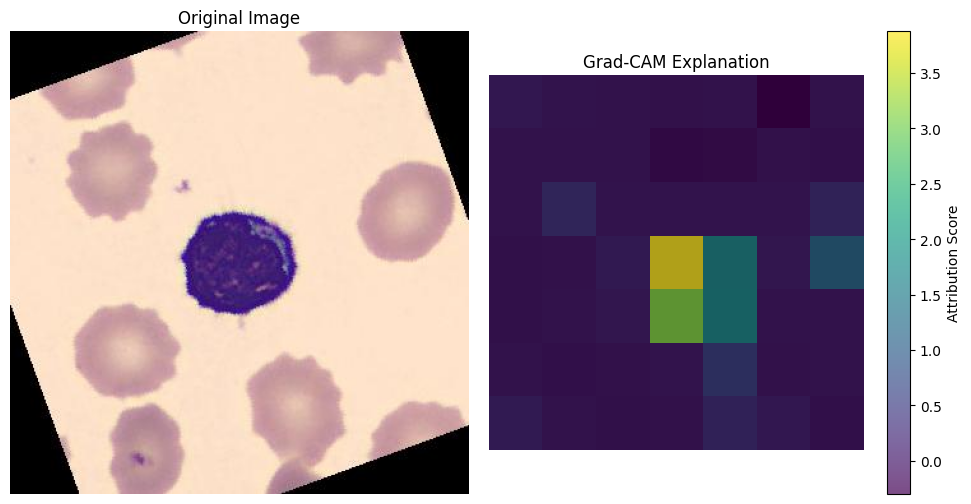

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Original image
ax[0].imshow(img)
ax[0].set_title("Original Image")
ax[0].axis('off')

# Grad-CAM heatmap overlay
ax[1].imshow(img)
im = ax[1].imshow(attribution_heatmap, cmap='viridis', alpha=0.7)
ax[1].set_title("Grad-CAM Explanation")
ax[1].axis('off')

# Add a color bar
cbar = fig.colorbar(im, ax=ax[1], orientation='vertical')
cbar.set_label('Attribution Score')

plt.tight_layout()
plt.show()

In [13]:
from torchvision import models, transforms,datasets
from torch.utils.data import DataLoader

transform=transforms.Compose([transforms.Resize((224,224)),transforms.ToTensor()])
dataset_train=datasets.ImageFolder(root='../../../Spanish Dataset/train_test_val_data/train_oversampling',transform=transform)
class_names=dataset_train.classes
dataset_test=datasets.ImageFolder(root='../../../Spanish Dataset/train_test_val_data/test',transform=transform)
print(dataset_test.classes)
dataset_val=datasets.ImageFolder(root='../../../Spanish Dataset/train_test_val_data/val',transform=transform)
dataloader_train=DataLoader(dataset_train,batch_size=32,shuffle=True)
dataloader_test=DataLoader(dataset_test,batch_size=32,shuffle=True)
dataloader_val=DataLoader(dataset_val,batch_size=32,shuffle=True)

['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


In [19]:
with torch.no_grad():
    output = model(input_batch)

# Get the predicted class index
predicted_index = torch.argmax(output).item()

# Assuming you have a list of class names from your dataset
# class_names = dataset_train.classes
print(f"Model prediction: {class_names[predicted_index]}")
print(f"Target index used for Grad-CAM: {class_names[lymphocyte_index]}")

Model prediction: lymphocyte
Target index used for Grad-CAM: lymphocyte


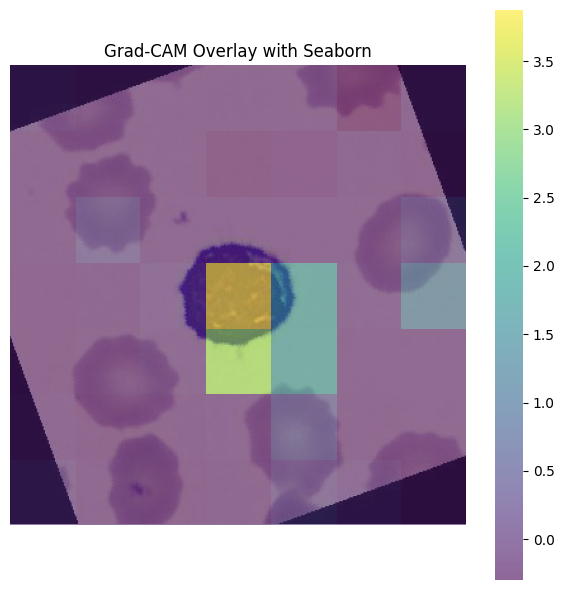

In [38]:
import seaborn as sns

resized_attribution = F.interpolate(attribution, size=(original_img_size[1], original_img_size[0]), mode='nearest')

# Convert to a numpy array
attribution_np = resized_attribution.squeeze().detach().cpu().numpy()

# Create a single plot
fig, ax = plt.subplots(figsize=(6, 6))

# Display the original image first
ax.imshow(img)

# Overlay the heatmap using seaborn.heatmap
sns.heatmap(attribution_np,
            ax=ax,
            cmap='viridis',
            alpha=0.6,
            cbar=True,
            xticklabels=False,
            yticklabels=False)

ax.set_title("Grad-CAM Overlay with Seaborn")
ax.axis('off')

plt.tight_layout()
plt.show()

In [39]:
with torch.no_grad():
    output = model(input_batch)

# Get the probability scores using the softmax function
probabilities = torch.nn.functional.softmax(output, dim=1)[0]
# Get the predicted class index and confidence
confidence, predicted_index = torch.max(probabilities, 0)

# Assuming you have a list of class names from your dataset
# class_names = dataset_train.classes
print(f"Model prediction: {class_names[predicted_index]}")
print(f"Confidence score: {confidence.item():.4f}")
print(f"Target index used for Grad-CAM: {class_names[lymphocyte_index]}")

Model prediction: lymphocyte
Confidence score: 1.0000
Target index used for Grad-CAM: lymphocyte
